# GELECTRA Large – Three-Class German AI Text Detection

This notebook fine-tunes **GELECTRA Large** for three-class classification of German text. The model distinguishes between **human-written**, **AI-generated**, and **AI-assisted** text.

The workflow covers the complete modeling pipeline, including dataset loading, tokenization, model fine-tuning, validation-based model selection, probability calibration, final evaluation, confusion-matrix analysis, error analysis, artifact export, and inference with the saved model.

The objective is to evaluate whether a larger German ELECTRA-based transformer can reliably identify different text-generation processes while producing reproducible and well-calibrated predictions.

## 1. Imports

This section imports the libraries required for data handling, model training, evaluation, calibration, artifact management, and reproducibility. It includes PyTorch, Hugging Face Transformers and Datasets, NumPy, pandas, and scikit-learn utilities used throughout the notebook.

In [42]:
import numpy as np
import pandas as pd
import torch
import json
import platform
import gc
import time
from transformers.utils import logging
from sklearn.model_selection import train_test_split


from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from sklearn.metrics import accuracy_score

## 2. Load Dataset

This section loads the preprocessed three-class Hugging Face dataset from disk. The dataset contains the existing **train**, **validation**, and **test** splits used throughout the experiment for model training, model selection, and final evaluation.

In [8]:
from datasets import load_from_disk

dataset = load_from_disk(
    "hf-dataset-3class-full"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 2906
    })
    test: Dataset({
        features: ['id', 'file', 'text', 'label', 'lan

## 3. Tokenization and Model Initialization

This section initializes the **GELECTRA Large tokenizer** and prepares the dataset for transformer-based training. Each text is tokenized with truncation to a maximum sequence length of **512 tokens**, while non-label columns are removed from the tokenized dataset.

The pretrained `deepset/gelectra-large` model is then loaded for **three-class sequence classification** with the label mapping:

- `0` → Human
- `1` → AI
- `2` → AI-assisted

A new classification head is initialized on top of the pretrained GELECTRA encoder and will be fine-tuned on the project dataset.

In [17]:

logging.set_verbosity_error()


MODEL_NAME = "deepset/gelectra-large"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


columns_to_remove = [
    column
    for column in dataset["train"].column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "HUMAN",
        1: "AI",
        2: "AI_ASSISTED",
    },
    label2id={
        "HUMAN": 0,
        "AI": 1,
        "AI_ASSISTED": 2,
    },
)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

## 4. Dynamic Padding

Pads each batch efficiently during training and evaluation.

In [18]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

## 5. Evaluation Metric

Calculates classification accuracy from the model predictions.

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        )
    }

## 6. Training Configuration

Defines the main hyperparameters and checkpointing strategy for fine-tuning.

In [20]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        )
    }

## 7. Trainer Initialization

Initializes the Hugging Face Trainer with the model, datasets, padding, and evaluation metric.

In [27]:
use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

training_args = TrainingArguments(
    output_dir="checkpoints-gelectra-large",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,
    warmup_steps=235,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=2,

    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,

    disable_tqdm=False,
    report_to="none",

    seed=17,
    data_seed=17,
)

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

In [29]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.252959,0.285112,0.930489
2,0.105559,0.167537,0.965244
3,0.030576,0.242504,0.963524


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Probability calibration

Use the validation split to learn a temperature-scaling parameter for GELECTRA.
Temperature scaling adjusts the confidence of the model's predicted probabilities
without changing the predicted class labels.

In [30]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)

validation_logits = np.asarray(
    validation_output.predictions
)

y_validation = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)


def fit_temperature(logits, labels):

    logits_tensor = torch.tensor(
        logits,
        dtype=torch.float64,
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long,
    )

    log_temperature = torch.nn.Parameter(
        torch.zeros(
            (),
            dtype=torch.float64,
        )
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()

        temperature = log_temperature.exp()

        loss = criterion(
            logits_tensor / temperature,
            labels_tensor,
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    return float(
        log_temperature.exp().detach()
    )


def probabilities_from_logits(
    logits,
    temperature=1.0,
):

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / temperature
    )

    scaled_logits -= scaled_logits.max(
        axis=1,
        keepdims=True,
    )

    exponentiated = np.exp(
        scaled_logits
    )

    return (
        exponentiated
        / exponentiated.sum(
            axis=1,
            keepdims=True,
        )
    )


GELECTRA_TEMPERATURE = fit_temperature(
    validation_logits,
    y_validation,
)

print(
    f"Learned GELECTRA temperature: "
    f"{GELECTRA_TEMPERATURE:.4f}"
)

Learned GELECTRA temperature: 1.9105


### Calibration evaluation

Compare GELECTRA's probability quality before and after temperature scaling.
The Brier score and log loss measure how well the predicted probabilities match
the true class labels, with lower values indicating better calibration.

In [31]:
from sklearn.metrics import log_loss
import numpy as np
import pandas as pd


def multiclass_brier_score(y_true, probabilities, n_classes=3):

    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


uncalibrated_validation_probabilities = probabilities_from_logits(
    validation_logits
)

calibrated_validation_probabilities = probabilities_from_logits(
    validation_logits,
    GELECTRA_TEMPERATURE,
)


calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",

            "Brier score": multiclass_brier_score(
                y_validation,
                uncalibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                uncalibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },

        {
            "model": "Temperature-scaled",

            "Brier score": multiclass_brier_score(
                y_validation,
                calibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                calibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },
    ]
).set_index("model")


calibration_comparison.style.format(
    "{:.4f}"
)

,Brier score,Log loss
model,,
Uncalibrated,0.0641,0.1675
Temperature-scaled,0.0573,0.1126


### Final split evaluation

Evaluate the calibrated model on the training, validation, and test splits using
accuracy, multiclass Brier score, log loss, and confusion matrices.

In [32]:
from sklearn.metrics import confusion_matrix
split_logits = {
    "validation": validation_logits
}

for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )

    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def multiclass_brier_score(
    y_true,
    probabilities,
    n_classes=3,
):
    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


def evaluate_split(split_name):

    y_true = np.asarray(
        dataset[split_name]["label"],
        dtype=np.int64,
    )

    probabilities = probabilities_from_logits(
        split_logits[split_name],
        GELECTRA_TEMPERATURE,
    )

    y_pred = np.argmax(
        probabilities,
        axis=1,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    return {
        "split": split_name,

        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "brier_score": multiclass_brier_score(
            y_true,
            probabilities,
        ),

        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1, 2],
        ),

        "confusion_matrix": cm,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")


evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,confusion_matrix
split,,,,
train,99.38%,0.0102,0.0333,[[8287 1 54] [ 4 8279 41] [ 53 1 8266]]
validation,96.52%,0.0573,0.1126,[[916 0 55] [ 2 950 15] [ 27 2 939]]
test,96.89%,0.0535,0.1095,[[871 1 42] [ 0 898 14] [ 28 0 883]]


### Test-set confusion matrix

Visualize the three-class confusion matrix on the test split to inspect which
classes are predicted correctly and where misclassifications occur.

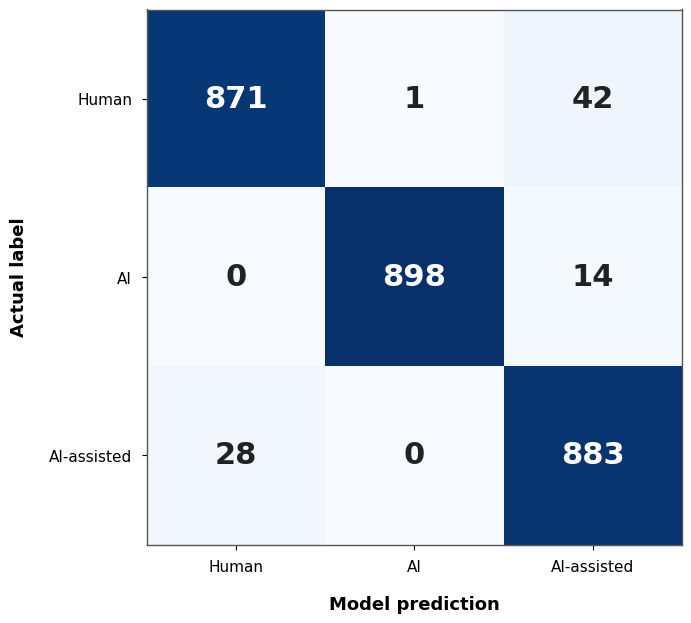

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    GELECTRA_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
)

class_names = [
    "Human",
    "AI",
    "AI-assisted",
]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(3):
    for column in range(3):

        value = test_matrix[row, column]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=22,
            fontweight="bold",
        )

ax.set_xticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_yticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "gelectra-large-confmat-3class.svg"
)

plt.show()

### Binary Human-vs-AI confusion matrix

Evaluate the model only on Human and fully AI-generated test samples. AI-assisted
samples are excluded, and the remaining Human and AI probabilities are
renormalized before applying a binary decision threshold.

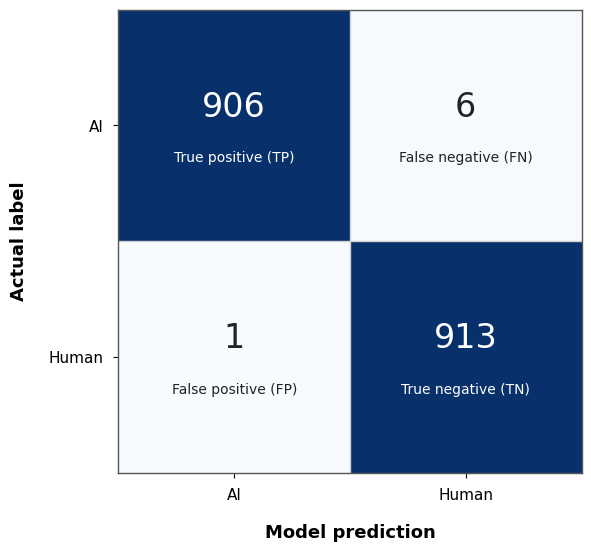

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Keep only Human (0) and AI (1)
y_test_all = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

mask = y_test_all != 2

y_test = y_test_all[mask]

test_logits_binary = split_logits["test"][mask]

# Apply GELECTRA temperature scaling
test_probabilities = probabilities_from_logits(
    test_logits_binary,
    GELECTRA_TEMPERATURE,
)

# Keep only Human and AI probabilities
human_prob = test_probabilities[:, 0]
ai_prob = test_probabilities[:, 1]

# Renormalize because AI-assisted is removed
total = human_prob + ai_prob

human_prob = human_prob / total
ai_prob = ai_prob / total

# Binary prediction
y_test_pred = (
    ai_prob >= 0.5
).astype(np.int64)

# AI first, then Human
test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[1, 0],
)

cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(2):
    for column in range(2):

        value = test_matrix[
            row,
            column
        ]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )

        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )

ax.set_xticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_yticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.axhline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.axvline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "gelectra-large-confmat-human-ai.svg"
)

plt.show()

### Error analysis

Inspect the highest-confidence misclassifications on the test set, including the
true label, predicted class, calibrated class probabilities, source information,
generator metadata, and a short text preview.

In [35]:
label_names = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    GELECTRA_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

prediction_confidence = np.max(
    test_probabilities,
    axis=1,
)

test_errors = pd.DataFrame(
    {
        "id": dataset["test"]["id"],

        "actual": [
            label_names[label]
            for label in y_test
        ],

        "prediction": [
            label_names[label]
            for label in y_test_pred
        ],

        "prediction_confidence": prediction_confidence,

        "human_probability": test_probabilities[:, 0],
        "ai_probability": test_probabilities[:, 1],
        "ai_assisted_probability": test_probabilities[:, 2],

        "source_name": dataset["test"]["source_name"],

        "generator_model": dataset["test"]["generator_model"],

        "text": [
            text[:300]
            for text in dataset["test"]["text"]
        ],
    }
)

# Keep only mistakes
test_errors = test_errors[
    test_errors["actual"]
    != test_errors["prediction"]
].copy()

test_errors.sort_values(
    "prediction_confidence",
    ascending=False,
).head(20).style.format(
    {
        "prediction_confidence": "{:.2%}",
        "human_probability": "{:.2%}",
        "ai_probability": "{:.2%}",
        "ai_assisted_probability": "{:.2%}",
    }
)

,id,actual,prediction,prediction_confidence,human_probability,ai_probability,ai_assisted_probability,source_name,generator_model,text
1572,17803,AI,AI-assisted,98.59%,0.96%,0.45%,98.59%,peDOCS (DIPF),gpt-6-luna,"Fridays for Future ist nicht allein als Protestbewegung zu verstehen, sondern ebenso als Impulsgeberin für Lernprozesse in unterschiedlichen Bildungsbereichen. Ihre öffentliche Präsenz hat die Klimakrise in bestehende Erwachsenenbildungsangebote eingebracht und zugleich neue Formate angeregt. So füh"
1645,18518,AI,AI-assisted,98.51%,0.89%,0.61%,98.51%,SSOAR,gpt-6-luna,"An der FernUniversität in Hagen widmet sich das Lehrgebiet Multimedia und Internetanwendungen seit Langem der dauerhaften Sicherung digitaler Daten. Ein Schwerpunkt liegt darauf, Daten mit ergänzenden Informationen auszustatten, damit sie auch künftig sinnvoll weiterverwendet werden können. Darüber"
991,11201,AI,AI-assisted,98.48%,0.59%,0.92%,98.48%,SSOAR,gpt-5.6-luna,"Im Fußball hat sich in den vergangenen Jahren ein zunehmend vielfältiges Instrumentarium zur Prävention von Rechtsextremismus, Rassismus und Fremdenfeindlichkeit herausgebildet. Dieses umfasst sowohl ordnungspolitische Maßnahmen als auch pädagogische, beratende und kommunikative Ansätze. Die bisheri"
1224,13840,AI,AI-assisted,98.36%,0.94%,0.70%,98.36%,SSOAR,gemini,Im Feld internationaler Konfliktbearbeitung nehmen die Vereinten Nationen weiterhin eine herausragende Vermittlungsrolle ein: Keine andere internationale Organisation tritt so häufig als Mediatorin in zwischenstaatlichen und innerstaatlichen Konflikten auf (Bercovitch & Schneider 2000: 156; Greig &
1102,12558,AI,AI-assisted,98.13%,1.26%,0.62%,98.13%,SSOAR,gpt-5.6-luna,"Beratung lässt sich sowohl als gesellschaftlich wirksamer Impuls für Veränderungsprozesse als auch als Unterstützung bei der individuellen Konstruktion von Biografie und Identität verstehen (Dewe/ Schwarz 2013: 13). Daraus ergibt sich die weiterführende Frage, welche gesellschaftlichen Aufgaben Bera"
1365,15166,AI,AI-assisted,97.75%,1.70%,0.55%,97.75%,Refubium (FU Berlin),gemini,"Claudia Anna Grässner, M. A. (Humboldt-Universität zu Berlin, Exzellenzcluster Topoi, E-I Knowledge of Ancient Spaces as Processed by the Arts), untersucht in ihrem Beitrag „Oszillation von Raumwissen“, wie räumliche Konstellationen Wissen hervorbringen, stabilisieren und zugleich in Bewegung verset"
301,3529,Human,AI-assisted,97.63%,2.00%,0.38%,97.63%,SSOAR,None,"Die Ergebnisse der Interviewstudie zeigen, dass Bildung nicht vor ausgrenzendem Denken schützt. Gerade der Fall Sven aus Klasse 4 macht darauf aufmerksam, dass eine gute Bildung, sozialer Einfluss und ein hohes Maß an Selbstbewusstsein durchaus mit einer Affinität zu extrem rechten Denkweisen einher"
191,2337,Human,AI-assisted,97.62%,1.97%,0.41%,97.62%,SSOAR,None,"Vielmehr projiziert er die eigene Bedürftigkeit unmittelbar auf das Gegenüber, das er zugleich für die Erfüllung seiner Bedürfnisse zu instrumentalisieren versucht. Von daher realisiert sich insbesondere bei diesem Typus die These vom sogenannten Seelsorgepaar, bei dem der/die Seelsorger*in dem/der"
199,2398,Human,AI-assisted,97.37%,2.21%,0.43%,97.37%,SSOAR,None,"Dies kann als eine Kampfansage an die sozialwissenschaftliche Technikfolgenforschung verstanden werden; denn er formuliert explizit sein Anliegen, den Blick auf die gesellschaftlichen Voraussetzungen der Digitalisierung statt auf deren gesellschaftliche Folgen zu richten. Auf diese Weise entledigt e"
156,1824,Human,AI-assisted,97.36%,2.14%,0.50%,97.36%,SSOAR,None,"Initiiert wurde das Netzwerk, weil die Bezugnahme auf und die Rekonstruktion von wirtschaftswissenschaftlichem Wissen von der deutschsprachigen Soziologie – verglichen mit der englischsprachigen Debatte – noch relativ wenig erforscht wurde. Ziel des Zusammenschlusses ist es daher, die Entwicklung ei"


### Model export

Save the fine-tuned model and tokenizer together with the calibration parameter,
label mapping, validation performance, training configuration, and software
versions required to reproduce inference.

In [36]:
RANDOM_STATE = 17
from pathlib import Path
from importlib.metadata import version
import platform
import json
import numpy as np

from sklearn.metrics import accuracy_score


# ============================================================
# ARTIFACT DIRECTORY
# ============================================================

ARTIFACT_DIR = Path("artifacts") / "gelectra-large-3class"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# SAVE MODEL + TOKENIZER
# ============================================================

trainer.save_model(
    ARTIFACT_DIR
)

tokenizer.save_pretrained(
    ARTIFACT_DIR
)


# ============================================================
# VALIDATION ACCURACY
# ============================================================

validation_predictions = np.argmax(
    validation_logits,
    axis=1,
)

best_validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)


# ============================================================
# METADATA
# ============================================================

metadata = {
    "dataset": "hf-dataset-3class-full",

    "base_model": MODEL_NAME,

    "label_mapping": {
        "human": 0,
        "ai": 1,
        "ai_assisted": 2,
    },

    "max_length": MAX_LENGTH,

    "calibration": "temperature scaling",

    "temperature": float(
        GELECTRA_TEMPERATURE
    ),

    "best_validation_accuracy": float(
        best_validation_accuracy
    ),

    "best_checkpoint": (
        trainer.state.best_model_checkpoint
    ),

    "random_state": RANDOM_STATE,

    "python_version": platform.python_version(),

    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}


# ============================================================
# SAVE METADATA
# ============================================================

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)


# ============================================================
# OUTPUT
# ============================================================

print(
    f"Saved model and tokenizer to: "
    f"{ARTIFACT_DIR}"
)

print(
    f"Saved detector configuration to: "
    f"{METADATA_PATH}"
)

print(
    f"Validation accuracy: "
    f"{best_validation_accuracy:.2%}"
)

print(
    f"Temperature: "
    f"{GELECTRA_TEMPERATURE:.4f}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: artifacts/gelectra-large-3class
Saved detector configuration to: artifacts/gelectra-large-3class/detector-config.json
Validation accuracy: 96.52%
Temperature: 1.9105


### Reload and test the exported model

Reload the saved model, tokenizer, and detector configuration from the artifact
directory, move the model to the available inference device, and run a sample
prediction using the stored temperature-scaling parameter.

In [37]:
from pathlib import Path
import json
import torch
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)


# ============================================================
# GELECTRA ARTIFACT PATH
# ============================================================

ARTIFACT_DIR = Path("artifacts") / "gelectra-large-3class"

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)


# ============================================================
# LOAD MODEL + TOKENIZER + CONFIG
# ============================================================

loaded_tokenizer = AutoTokenizer.from_pretrained(
    ARTIFACT_DIR
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)

loaded_config = json.loads(
    METADATA_PATH.read_text(
        encoding="utf-8"
    )
)


# ============================================================
# DEVICE
# ============================================================

if torch.cuda.is_available():
    inference_device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    inference_device = torch.device("mps")

else:
    inference_device = torch.device("cpu")


print("Device:", inference_device)


loaded_model.to(
    inference_device
)

loaded_model.eval()


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_probabilities(texts):

    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    )

    inputs = {
        key: value.to(inference_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():

        logits = loaded_model(
            **inputs
        ).logits

        calibrated_logits = (
            logits
            / loaded_config["temperature"]
        )

        probabilities = torch.softmax(
            calibrated_logits,
            dim=1,
        )

    return probabilities.cpu().numpy()


# ============================================================
# LABELS
# ============================================================

id2label = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}


# ============================================================
# EXAMPLE
# ============================================================

texts = [
    """
   Die systematische Gegenüberstellung unterschiedlicher Klassifikationsmodelle erfordert einheitliche Rahmenbedingungen, damit die erzielten Ergebnisse tatsächlich vergleichbar sind. Dazu gehören identische Trainings-, Validierungs- und Testdaten sowie eine konsistente Vorverarbeitung der Texte. Neben der Gesamtgenauigkeit sollten auch differenzierte Kennzahlen wie der Macro-F1-Wert und die Anzahl falsch positiver Klassifikationen berücksichtigt werden, da fälschlich als KI-generiert eingestufte menschliche Texte in der Praxis erhebliche Folgen haben können. Ergänzend empfiehlt sich eine Evaluation auf Texten aus anderen Genres, um die Robustheit der Verfahren unabhängig vom Trainingsumfeld zu beurteilen.
   """
]


probabilities = predict_probabilities(
    texts
)


for text, probs in zip(
    texts,
    probabilities,
):

    prediction = int(
        np.argmax(probs)
    )

    label = id2label[
        prediction
    ]

    print(
        f"Prediction: {label}"
    )

    print(
        f"Human:       {probs[0]:.1%}"
    )

    print(
        f"AI:          {probs[1]:.1%}"
    )

    print(
        f"AI-assisted: {probs[2]:.1%}"
    )

    print(
        f"\n{text}"
    )

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Device: cuda
Prediction: AI
Human:       0.2%
AI:          99.4%
AI-assisted: 0.4%


   Die systematische Gegenüberstellung unterschiedlicher Klassifikationsmodelle erfordert einheitliche Rahmenbedingungen, damit die erzielten Ergebnisse tatsächlich vergleichbar sind. Dazu gehören identische Trainings-, Validierungs- und Testdaten sowie eine konsistente Vorverarbeitung der Texte. Neben der Gesamtgenauigkeit sollten auch differenzierte Kennzahlen wie der Macro-F1-Wert und die Anzahl falsch positiver Klassifikationen berücksichtigt werden, da fälschlich als KI-generiert eingestufte menschliche Texte in der Praxis erhebliche Folgen haben können. Ergänzend empfiehlt sich eine Evaluation auf Texten aus anderen Genres, um die Robustheit der Verfahren unabhängig vom Trainingsumfeld zu beurteilen.
   


### Length-based evaluation

Evaluate GELECTRA's performance across different text-length ranges to identify whether classification accuracy and class-specific error rates vary with document length.

In [38]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

texts = np.asarray(
    dataset["test"]["text"],
    dtype=object,
)

test_logits = split_logits["test"]

test_probabilities = probabilities_from_logits(
    test_logits,
    GELECTRA_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

word_lengths = np.asarray([
    len(text.split())
    for text in texts
])

length_bins = [
    (0, 70, "≤70"),
    (71, 150, "71–150"),
    (151, 300, "151–300"),
    (301, 500, "301–500"),
    (501, 750, "501–750"),
    (751, np.inf, "750+"),
]

rows = []

for lower, upper, name in length_bins:
    bin_mask = (
        (word_lengths >= lower)
        & (word_lengths <= upper)
    )

    y_bin = y_test[bin_mask]
    pred_bin = y_test_pred[bin_mask]
    probabilities_bin = test_probabilities[
        bin_mask
    ]

    if len(y_bin) == 0:
        continue

    human_mask = y_bin == 0
    ai_mask = y_bin == 1
    ai_assisted_mask = y_bin == 2

    mean_human_score = (
        probabilities_bin[
            human_mask,
            0
        ].mean() * 100
    )

    mean_ai_score = (
        probabilities_bin[
            ai_mask,
            1
        ].mean() * 100
    )

    mean_ai_assisted_score = (
        probabilities_bin[
            ai_assisted_mask,
            2
        ].mean() * 100
    )

    human_error_rate = np.mean(
        pred_bin[human_mask] != 0
    )

    ai_error_rate = np.mean(
        pred_bin[ai_mask] != 1
    )

    ai_assisted_error_rate = np.mean(
        pred_bin[ai_assisted_mask] != 2
    )

    rows.append(
        {
            "model": "GELECTRA-large",
            "length_bin": name,
            "samples": len(y_bin),
            "human_samples": human_mask.sum(),
            "ai_samples": ai_mask.sum(),
            "ai_assisted_samples": ai_assisted_mask.sum(),
            "accuracy": accuracy_score(
                y_bin,
                pred_bin,
            ),
            "mean_human_score": mean_human_score,
            "mean_ai_score": mean_ai_score,
            "mean_ai_assisted_score": mean_ai_assisted_score,
            "human_error_rate": human_error_rate,
            "ai_error_rate": ai_error_rate,
            "ai_assisted_error_rate": ai_assisted_error_rate,
        }
    )

gelectra_length_results_3class = pd.DataFrame(
    rows
)

gelectra_length_results_3class

,model,length_bin,samples,human_samples,ai_samples,ai_assisted_samples,accuracy,mean_human_score,mean_ai_score,mean_ai_assisted_score,human_error_rate,ai_error_rate,ai_assisted_error_rate
0,GELECTRA-large,≤70,399,134,134,131,0.907268,83.255081,91.728844,88.421678,0.126866,0.074627,0.076336
1,GELECTRA-large,71–150,293,94,122,77,0.972696,92.641583,98.600091,94.487251,0.042553,0.008197,0.038961
2,GELECTRA-large,151–300,640,207,245,188,0.976562,92.663727,99.340439,95.790232,0.053140,0.000000,0.021277
3,GELECTRA-large,301–500,342,106,89,147,0.982456,93.953593,98.902675,97.415631,0.037736,0.000000,0.013605
4,GELECTRA-large,501–750,653,233,191,229,0.978560,95.968122,97.924001,94.897362,0.012876,0.015707,0.034934
5,GELECTRA-large,750+,410,140,131,139,0.987805,94.063010,99.357204,97.097574,0.028571,0.000000,0.007194


### Learning-curve analysis

Train fresh mmBERT-small models on increasing fractions of the training data and
measure training accuracy, validation accuracy, generalization gap, and training
runtime. Each fraction starts from the same pretrained checkpoint to make the
comparison consistent.

In [51]:
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()

TRAINING_FRACTIONS = [
    0.01,
    0.12,
    0.25,
    0.5,
    1.0,
]

train_labels = np.asarray(
    dataset["train"]["label"],
    dtype=np.int64,
)

all_indices = np.arange(
    len(dataset["train"])
)

learning_curve_rows = []

for fraction in TRAINING_FRACTIONS:
    if fraction < 1.0:
        subset_indices, _ = train_test_split(
            all_indices,
            train_size=fraction,
            stratify=train_labels,
            random_state=RANDOM_STATE,
        )

    else:
        subset_indices = all_indices

    train_subset = tokenized_dataset["train"].select(
        subset_indices.tolist()
    )

    model_fraction = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label={
            0: "HUMAN",
            1: "AI",
            2: "AI_ASSISTED",
        },
        label2id={
            "HUMAN": 0,
            "AI": 1,
            "AI_ASSISTED": 2,
        },
    )

    fraction_args = TrainingArguments(
        output_dir=(
            f"learning-curve-gelectra-large/"
            f"{fraction}"
        ),

        learning_rate=2e-5,

        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,

        num_train_epochs=3,

        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="no",

        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,

        save_total_limit=1,

        bf16=use_bf16,
        fp16=(
            torch.cuda.is_available()
            and not use_bf16
        ),

        report_to="none",

        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
    )

    fraction_trainer = Trainer(
        model=model_fraction,
        args=fraction_args,

        train_dataset=train_subset,
        eval_dataset=tokenized_dataset["validation"],

        processing_class=tokenizer,
        data_collator=data_collator,

        compute_metrics=compute_metrics,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=1
            )
        ],
    )

    start_time = time.perf_counter()

    fraction_trainer.train()

    runtime = (
        time.perf_counter()
        - start_time
    )

    train_output = fraction_trainer.predict(
        train_subset
    )

    train_predictions = np.argmax(
        train_output.predictions,
        axis=1,
    )

    training_accuracy = accuracy_score(
        train_output.label_ids,
        train_predictions,
    )

    validation_output = fraction_trainer.predict(
        tokenized_dataset["validation"]
    )

    validation_predictions = np.argmax(
        validation_output.predictions,
        axis=1,
    )

    validation_accuracy = accuracy_score(
        validation_output.label_ids,
        validation_predictions,
    )

    learning_curve_rows.append(
        {
            "training_samples": len(train_subset),
            "training_fraction": fraction,
            "training_accuracy": training_accuracy,
            "validation_accuracy": validation_accuracy,
            "generalization_gap":
                training_accuracy - validation_accuracy,
            "training_runtime_seconds": runtime,
        }
    )

    del fraction_trainer
    del model_fraction

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


gelectra_learning_curve = pd.DataFrame(
    learning_curve_rows
)

gelectra_learning_curve

,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,249,0.01,0.863454,0.747419,0.116035,49.173105
1,2998,0.12,0.990327,0.949071,0.041256,207.789741
2,6246,0.25,0.993596,0.952512,0.041084,366.829758
3,12493,0.50,0.993516,0.959738,0.033778,759.593660
